# ลบข้อมูลหัวข้อแถวแรก ซึ่งเป็นข้อมูลออก แล้วบันทึกไฟล์เป็นชื่อใหม่

In [1]:
# Open the original file for reading
with open("dataset/P100_No_Reacg2.txt", "r") as text_file:
    # Read all lines into a list
    lines = text_file.readlines()

# Check if there are lines in the file
if len(lines) > 0:
    # Create a new file name with "n" added
    new_filename = "dataset/P100_No_Reacg2n.txt"

    # Open the new file for writing
    with open(new_filename, "w") as new_file:
        # Write all lines except the first one to the new file
        new_file.writelines(lines[1:])

    print(f"New file '{new_filename}' created with lines except the first one.")
else:
    print("The original file is empty.")

New file 'dataset/P100_No_Reacg2n.txt' created with lines except the first one.


# แสดงข้อมูล ใหม่

In [2]:
# read the file again store each line in a list
text_file = open("dataset/P100_No_Reacg2n.txt", "r")

lines = text_file.readlines()

# no of lines
print('No of lines in file is ',format(len(lines)))

# print each line text
for line in lines :
    print(line)

# close the file
text_file.close()

No of lines in file is  1800
1,1,White,4

2,2,White,830

3,3,White,822

4,4,White,832

5,5,White,832

6,6,White,823

7,7,White,833

8,8,White,826

9,9,White,828

10,10,White,831

11,11,White,818

12,12,White,834

13,13,White,829

14,14,White,831

15,1,Red,832

16,2,Red,343

17,3,Red,343

18,4,Red,343

19,5,Red,336

20,6,Red,343

21,7,Red,343

22,8,Red,345

23,9,Red,346

24,10,Red,348

25,11,Red,345

26,12,Red,341

27,13,Red,347

28,14,Red,339

29,15,Red,342

30,1,Green,338

31,2,Green,197

32,3,Green,198

33,4,Green,195

34,5,Green,197

35,6,Green,202

36,7,Green,198

37,8,Green,199

38,9,Green,199

39,10,Green,201

40,11,Green,201

41,12,Green,201

42,13,Green,201

43,14,Green,202

44,15,Green,197

45,1,Blue,202

46,2,Blue,336

47,3,Blue,335

48,4,Blue,337

49,5,Blue,337

50,6,Blue,337

51,7,Blue,337

52,8,Blue,333

53,9,Blue,331

54,10,Blue,337

55,11,Blue,332

56,12,Blue,336

57,13,Blue,334

58,14,Blue,331

59,1,Black,335

60,2,Black,6

61,3,Black,7

62,4,Black,5

63,5,Black,5

64,6

# Convert Txt File to CSV file

In [3]:
import csv

# Open the text file for reading
with open("dataset/P100_No_Reacg2n.txt", "r") as text_file:
    lines = text_file.readlines()

# Remove leading/trailing whitespace from each line and split on a delimiter (e.g., comma)
data = [line.strip().split(',') for line in lines]

# Determine the output file name by replacing the ".txt" extension with ".csv"
output_file_name = "datasetCSV/P100_No_Reacg2n.csv"

# Write the data to a CSV file
with open(output_file_name, "w", newline='') as csv_file:
    writer = csv.writer(csv_file)
    writer.writerows(data)

print(f"File '{output_file_name}' has been created with the CSV data.")


File 'datasetCSV/P100_No_Reacg2n.csv' has been created with the CSV data.


# เพิ่มหัวตารางในแถวแรก   ["No.", "Order", "Color", "Intensity"]  แล้วบันทึกข้อมูล

In [4]:
import pandas as pd

# Define the column names
column_names = ["No.", "Order", "Color", "Intensity"]

# Load the CSV file with the specified column names
file_path = "datasetCSV/P100_No_Reacg2n.csv"
df = pd.read_csv(file_path, names=column_names)

# Shift the data in the 'Intensity' column up by one row
df['Intensity'] = df['Intensity'].shift(-1)

# Drop rows where 'Order' is equal to 0 and 'Color' is equal to 'Black'
df = df[(df['Order'] != 0) | (df['Color'] != 'Black')]

# Drop rows where 'Order' is equal to 15
df = df[df['Order'] != 15]

# Specify the original file path and save the modified DataFrame
original_file_path = "datasetCSV/P100_No_Reacg2n.csv"
df.to_csv(original_file_path, index=False)

# Print the modified DataFrame
print("Modified DataFrame:")
print(df)

# Print a confirmation message
print(f"Modified DataFrame saved to {original_file_path}")


Modified DataFrame:
       No.  Order  Color  Intensity
0        1      1  White      830.0
1        2      2  White      822.0
2        3      3  White      832.0
3        4      4  White      832.0
4        5      5  White      823.0
...    ...    ...    ...        ...
1795  1796      5  Green      195.0
1796  1797      6  Green      196.0
1797  1798      7  Green      198.0
1798  1799      8  Green      201.0
1799  1800      9  Green        NaN

[1437 rows x 4 columns]
Modified DataFrame saved to datasetCSV/P100_No_Reacg2n.csv


In [6]:
# Group the DataFrame by 'Order' and 'Color' and calculate the mean and standard deviation of 'Intensity'
grouped_df = df.groupby(['Order', 'Color'])['Intensity'].agg(['mean', 'std']).reset_index()

# Print the resulting DataFrame
print("Mean and Standard Deviation of 'Intensity' by 'Order' and 'Color':")
print(grouped_df)


Mean and Standard Deviation of 'Intensity' by 'Order' and 'Color':
    Order  Color        mean       std
0       1  Black    6.100000  1.209611
1       1   Blue  330.700000  3.757099
2       1  Green  197.952381  2.036570
3       1    Red  339.666667  2.762849
4       1  White  821.666667  4.234777
..    ...    ...         ...       ...
65     14  Black    5.750000  1.118034
66     14   Blue  331.550000  3.394655
67     14  Green  198.250000  2.149051
68     14    Red  339.619048  2.692140
69     14  White  821.809524  4.996189

[70 rows x 4 columns]


In [9]:
# Define the new file name
new_file_name = "Table_" + original_file_path.split("/")[-1]

# Define the new file path by combining the original folder and the new file name
new_file_path = "/".join(original_file_path.split("/")[:-1]) + "/" + new_file_name

# Save the grouped DataFrame to the new file
grouped_df.to_csv(new_file_path, index=False)

# Print a confirmation message
print(f"Grouped DataFrame saved to {new_file_path}")


Grouped DataFrame saved to datasetCSV/Table_P100_No_Reacg2n.csv


In [11]:
# Create a pivot table with 'Order' as columns and 'Color' as index
pivot_df = grouped_df.pivot_table(values=['mean', 'std'], index='Color', columns='Order')

# Print the pivot table
print("Pivot Table:")
print(pivot_df)


Pivot Table:
             mean                                                              \
Order          1           2           3           4           5           6    
Color                                                                           
Black    6.100000    6.250000    5.800000    5.850000    6.050000    6.150000   
Blue   330.700000  332.100000  332.750000  332.700000  331.850000  331.550000   
Green  197.952381  197.761905  197.476190  197.333333  198.095238  196.714286   
Red    339.666667  339.333333  340.000000  338.666667  341.190476  340.523810   
White  821.666667  819.904762  822.095238  821.619048  821.095238  822.047619   

                                                       ...       std  \
Order          7           8           9           10  ...        5    
Color                                                  ...             
Black    6.450000    5.950000    6.250000    6.100000  ...  0.887041   
Blue   333.500000  332.650000  332.850000  331.450

In [14]:
# Pivot the grouped DataFrame to have 'Order' as columns and 'mean' and 'std' as values
pivot_df = grouped_df.pivot(index='Color', columns='Order', values=['mean', 'std'])

# Rename the columns to have 'Order' as the first level and 'mean' and 'std' as the second level
pivot_df.columns = [f'Order_{order}_{agg}' for order, agg in pivot_df.columns]

# Reset the index
pivot_df.reset_index(inplace=True)

# Print the pivoted DataFrame
print("Pivoted DataFrame:")
print(pivot_df)


Pivoted DataFrame:
   Color  Order_mean_1  Order_mean_2  Order_mean_3  Order_mean_4  \
0  Black      6.100000      6.250000      5.800000      5.850000   
1   Blue    330.700000    332.100000    332.750000    332.700000   
2  Green    197.952381    197.761905    197.476190    197.333333   
3    Red    339.666667    339.333333    340.000000    338.666667   
4  White    821.666667    819.904762    822.095238    821.619048   

   Order_mean_5  Order_mean_6  Order_mean_7  Order_mean_8  Order_mean_9  ...  \
0      6.050000      6.150000      6.450000      5.950000      6.250000  ...   
1    331.850000    331.550000    333.500000    332.650000    332.850000  ...   
2    198.095238    196.714286    197.666667    198.190476    197.700000  ...   
3    341.190476    340.523810    339.571429    341.666667    339.666667  ...   
4    821.095238    822.047619    821.666667    821.761905    821.619048  ...   

   Order_std_5  Order_std_6  Order_std_7  Order_std_8  Order_std_9  \
0     0.887041     0.

In [15]:
# Create a pivot table to show the mean and standard deviation for each Order
pivot_df = grouped_df.pivot_table(index='Order', columns='Color', values=['mean', 'std'])

# Rearrange the columns to have a multi-level index with Order as the top level and Color as the second level
pivot_df = pivot_df.swaplevel(axis=1)

# Sort the columns by Order
pivot_df = pivot_df.sort_index(axis=1, level=0, sort_remaining=False)

# Print the resulting DataFrame
print("Pivot Table with Order, Color, Mean, and Standard Deviation:")
print(pivot_df)


Pivot Table with Order, Color, Mean, and Standard Deviation:
Color Black              Blue                 Green                   Red  \
       mean       std    mean       std        mean       std        mean   
Order                                                                       
1      6.10  1.209611  330.70  3.757099  197.952381  2.036570  339.666667   
2      6.25  1.069924  332.10  3.322966  197.761905  2.998412  339.333333   
3      5.80  0.951453  332.75  3.958668  197.476190  2.400397  340.000000   
4      5.85  1.089423  332.70  3.357631  197.333333  2.869379  338.666667   
5      6.05  0.887041  331.85  3.407036  198.095238  3.192253  341.190476   
6      6.15  0.988087  331.55  3.456116  196.714286  3.378503  340.523810   
7      6.45  1.145931  333.50  2.417045  197.666667  2.175623  339.571429   
8      5.95  0.759155  332.65  2.007224  198.190476  2.542028  341.666667   
9      6.25  1.164158  332.85  3.133436  197.700000  2.754900  339.666667   
10     6.10  1.

In [17]:
# Swap the axes (Order and Color)
pivot_df_swapped = pivot_df.swapaxes(axis1=0, axis2=1)  # You can also use pivot_df.transpose()

# Print the resulting DataFrame
print("Pivot Table with Color as the top level and Order as the second level:")
print(pivot_df_swapped)


Pivot Table with Color as the top level and Order as the second level:
Order               1           2           3           4           5   \
     Color                                                               
mean Black    6.100000    6.250000    5.800000    5.850000    6.050000   
std  Black    1.209611    1.069924    0.951453    1.089423    0.887041   
mean Blue   330.700000  332.100000  332.750000  332.700000  331.850000   
std  Blue     3.757099    3.322966    3.958668    3.357631    3.407036   
mean Green  197.952381  197.761905  197.476190  197.333333  198.095238   
std  Green    2.036570    2.998412    2.400397    2.869379    3.192253   
mean Red    339.666667  339.333333  340.000000  338.666667  341.190476   
std  Red      2.762849    3.381321    3.209361    3.087610    2.619524   
mean White  821.666667  819.904762  822.095238  821.619048  821.095238   
std  White    4.234777    4.357806    3.300072    4.620348    3.793478   

Order               6           7       

/var/folders/x0/v1wddh8s0c32rk82mvdl7hf40000gn/T/ipykernel_69784/59714901.py:2: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  pivot_df_swapped = pivot_df.swapaxes(axis1=0, axis2=1)  # You can also use pivot_df.transpose()


In [18]:
# Group the DataFrame by 'Color' and calculate the mean and standard deviation of 'Intensity'
color_grouped_df = df.groupby('Color')['Intensity'].agg(['mean', 'std'])

# Print the resulting DataFrame
print("Mean and Standard Deviation of 'Intensity' by 'Color':")
print(color_grouped_df)


Mean and Standard Deviation of 'Intensity' by 'Color':
             mean       std
Color                      
Black    6.057143  1.049126
Blue   332.253571  3.152627
Green  197.701389  2.680631
Red    340.061224  3.038377
White  821.625850  4.171594


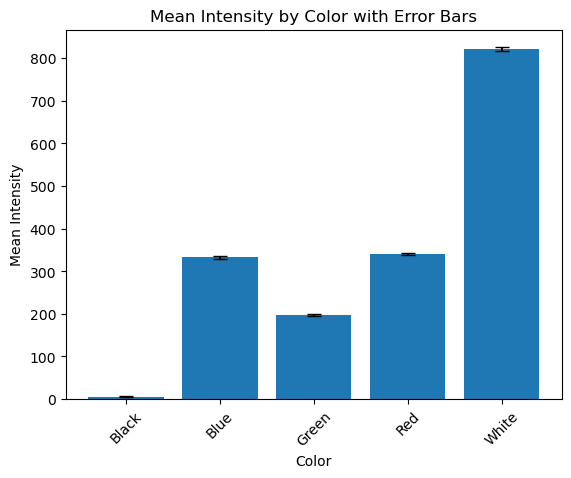

In [20]:
import matplotlib.pyplot as plt

# Group the DataFrame by 'Color' and calculate the mean and standard deviation of 'Intensity'
color_grouped_df = df.groupby('Color')['Intensity'].agg(['mean', 'std']).reset_index()

# Extract the 'Color', 'mean', and 'std' columns
colors = color_grouped_df['Color']
means = color_grouped_df['mean']
stds = color_grouped_df['std']

# Create a bar plot with error bars
plt.bar(colors, means, yerr=stds, capsize=5)

# Set labels and title
plt.xlabel('Color')
plt.ylabel('Mean Intensity')
plt.title('Mean Intensity by Color with Error Bars')

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Show the plot
plt.show()


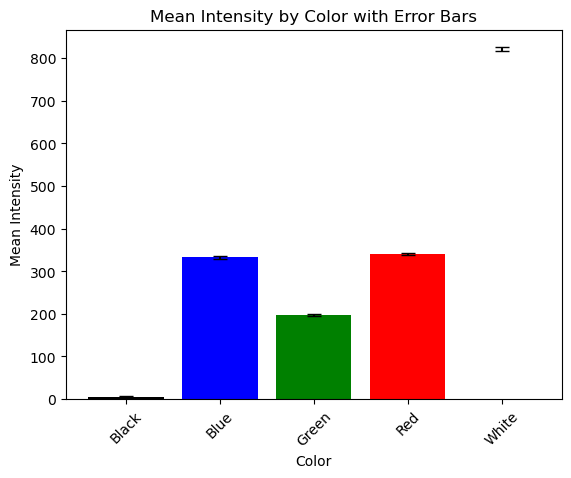

In [22]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# Group the DataFrame by 'Color' and calculate the mean and standard deviation of 'Intensity'
color_grouped_df = df.groupby('Color')['Intensity'].agg(['mean', 'std']).reset_index()

# Extract the 'Color', 'mean', and 'std' columns
colors = color_grouped_df['Color']
means = color_grouped_df['mean']
stds = color_grouped_df['std']

# Get a list of unique colors from the 'Color' column
unique_colors = color_grouped_df['Color'].unique()

# Create a list of rgba values for each color
rgba_colors = [to_rgba(color) for color in unique_colors]


# Create a bar plot with error bars and set color for each bar
for i, color in enumerate(unique_colors):
    color_means = means[colors == color]
    color_stds = stds[colors == color]
    plt.bar(i, color_means, yerr=color_stds, capsize=5, color=rgba_colors[i])

# Set xticks and labels
plt.xticks(range(len(unique_colors)), unique_colors, rotation=45)

# Set labels and title
plt.xlabel('Color')
plt.ylabel('Mean Intensity')
plt.title('Mean Intensity by Color with Error Bars')

# Show the plot
plt.show()


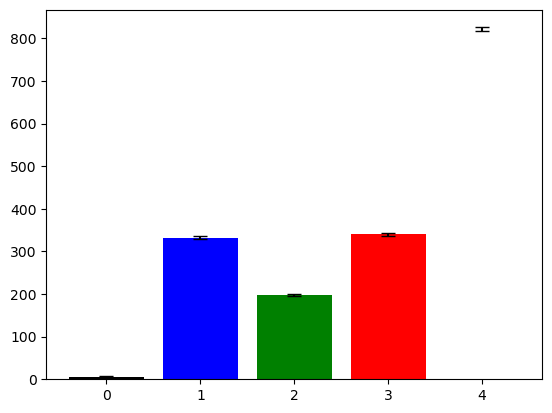

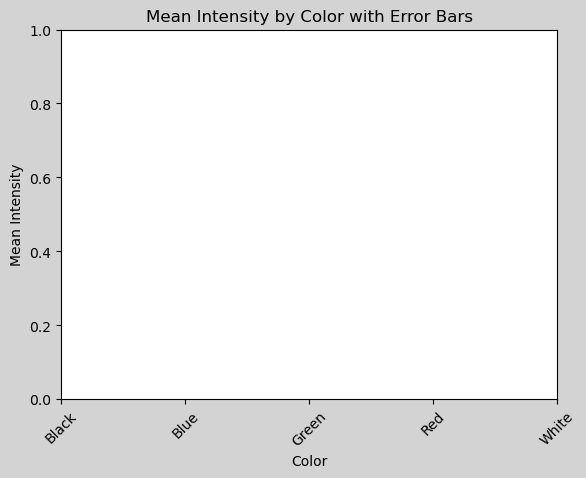

In [27]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# Group the DataFrame by 'Color' and calculate the mean and standard deviation of 'Intensity'
color_grouped_df = df.groupby('Color')['Intensity'].agg(['mean', 'std']).reset_index()

# Extract the 'Color', 'mean', and 'std' columns
colors = color_grouped_df['Color']
means = color_grouped_df['mean']
stds = color_grouped_df['std']

# Get a list of unique colors from the 'Color' column
unique_colors = color_grouped_df['Color'].unique()

# Create a list of rgba values for each color
rgba_colors = [to_rgba(color) for color in unique_colors]

# Create a bar plot with error bars and set color for each bar
for i, color in enumerate(unique_colors):
    color_means = means[colors == color]
    color_stds = stds[colors == color]
    plt.bar(i, color_means, yerr=color_stds, capsize=5, color=rgba_colors[i])

# Set the background color to a light color
fig = plt.figure()
fig.patch.set_facecolor('lightgray')

# Set xticks and labels
plt.xticks(range(len(unique_colors)), unique_colors, rotation=45)

# Set labels and title
plt.xlabel('Color')
plt.ylabel('Mean Intensity')
plt.title('Mean Intensity by Color with Error Bars')

# Show the plot
plt.show()


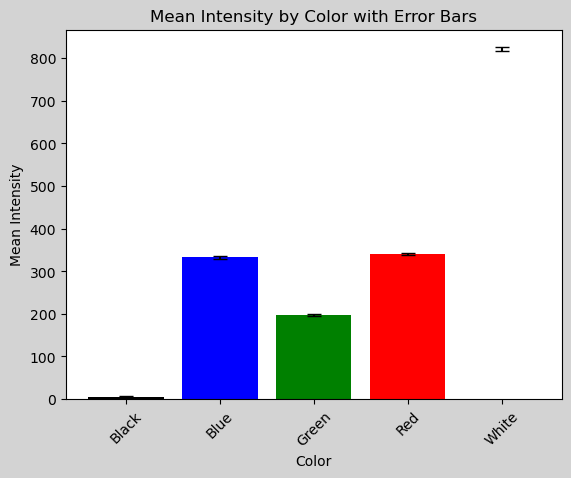

In [29]:
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# Group the DataFrame by 'Color' and calculate the mean and standard deviation of 'Intensity'
color_grouped_df = df.groupby('Color')['Intensity'].agg(['mean', 'std']).reset_index()

# Extract the 'Color', 'mean', and 'std' columns
colors = color_grouped_df['Color']
means = color_grouped_df['mean']
stds = color_grouped_df['std']

# Get a list of unique colors from the 'Color' column
unique_colors = color_grouped_df['Color'].unique()

# Create a list of rgba values for each color
rgba_colors = [to_rgba(color) for color in unique_colors]

# Create a figure with subplots
fig, ax = plt.subplots()

# Create a bar plot with error bars and set color for each bar
for i, color in enumerate(unique_colors):
    color_means = means[colors == color]
    color_stds = stds[colors == color]
    ax.bar(i, color_means, yerr=color_stds, capsize=5, color=rgba_colors[i])

# Set the background color to a light color
fig.patch.set_facecolor('lightgray')

# Set xticks and labels
ax.set_xticks(range(len(unique_colors)))
ax.set_xticklabels(unique_colors, rotation=45)

# Set labels and title
ax.set_xlabel('Color')
ax.set_ylabel('Mean Intensity')
ax.set_title('Mean Intensity by Color with Error Bars')

# Show the plot
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the column names
column_names = ["No.", "Order", "Color", "Intensity"]

# Load the CSV file with the specified column names
file_path = "datasetCSV/P100_No_Reacg2n.csv"
df = pd.read_csv(file_path, names=column_names)

# Convert 'Intensity' column to numeric
df['Intensity'] = pd.to_numeric(df['Intensity'], errors='coerce')

# Create a line plot using Matplotlib
plt.figure(figsize=(12, 6))
data_points = range(1, len(df) + 1)
intensity_values = df['Intensity']

plt.plot(data_points, intensity_values, marker='o', linestyle='-', markersize=2, color='blue')
plt.title('Intensity vs Data Point')
plt.xlabel('Data Point')
plt.ylabel('Intensity')

plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the column names
column_names = ["No.", "Order", "Color", "Intensity"]

# Load the CSV file with the specified column names
file_path = "datasetCSV/P100_No_Reacg2n.csv"
df = pd.read_csv(file_path, names=column_names)

# Convert 'Intensity' column to numeric
df['Intensity'] = pd.to_numeric(df['Intensity'], errors='coerce')

# Create a line plot for the specified range
start_index = 200
end_index = 600

plt.figure(figsize=(12, 6))
data_points = range(start_index, end_index + 1)
intensity_values = df['Intensity'].iloc[start_index-1:end_index]

plt.plot(data_points, intensity_values, marker='o', linestyle='-', markersize=2, color='red')
plt.title('Intensity vs Data Point (Range 200 - 600)')
plt.xlabel('Data Point')
plt.ylabel('Intensity')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the column names
column_names = ["No.", "Order", "Color", "Intensity"]

# Load the CSV file with the specified column names
file_path = "datasetCSV/P100_No_Reacg2n.csv"
df = pd.read_csv(file_path, names=column_names)

# Convert 'Intensity' column to numeric
df['Intensity'] = pd.to_numeric(df['Intensity'], errors='coerce')

# Define the range for the x-axis (data points)
start_data_point = 200
end_data_point = 300

# Filter the DataFrame for the specified range
filtered_df = df[(df.index >= start_data_point - 1) & (df.index <= end_data_point - 1)]

# Create a line plot for the filtered data
plt.figure(figsize=(12, 6))
data_points = range(start_data_point, end_data_point + 1)
intensity_values = filtered_df['Intensity']
colors = filtered_df['Color']

plt.plot(data_points, intensity_values, marker='o', linestyle='-', markersize=2, color='blue')
plt.title('Intensity vs Data Point (Data Points 200-300)')
plt.xlabel('Data Point')
plt.ylabel('Intensity')

# Show the Color values in a separate plot
plt.figure(figsize=(12, 3))
plt.bar(data_points, colors, color='green')
plt.title('Color vs Data Point (Data Points 200-300)')
plt.ylabel('Intensity')
plt.xlabel('Color')
plt.xticks(data_points, rotation=0)
plt.show()


# ลบข้อมูลที่ไม่ใช้ ออก พร้อมบันทึกไฟล์ชื่อใหม่

In [ ]:
import pandas as pd

# Define the column names
column_names = ["No.", "Order", "Color", "Intensity"]

# Load the CSV file with the specified column names
file_path = "datasetCSV/P100_No_Reacg2n.csv"
df = pd.read_csv(file_path, names=column_names)

# Shift the data in the 'Intensity' column up by one row
df['Intensity'] = df['Intensity'].shift(-1)

# Drop the last row of the DataFrame
df = df.drop(df.index[-1])

# Delete rows where 'Order' is 0 and 'Color' is 'Black'
df = df[(df['Order'] != 0) | (df['Color'] != 'Black')]

# Specify the new file path and save the modified DataFrame
new_output_file_path = "datasetCSV/P100_No_Reacg2n_modified.csv"  # Change this path as needed

# Print the modified DataFrame
print("Modified DataFrame:")
print(df)

# Save the modified DataFrame to the original file
df.to_csv(new_output_file_path, index=False)

# Print a confirmation message
print(f"Modified DataFrame saved to {new_output_file_path}")
